In [1]:
# import clr  # From pythonnet
import os
import random
import numpy as np
import pandas as pd
from sklearn.cluster import MeanShift
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import ParameterSampler, ParameterGrid
# from dwsim_parametric_study import parametric_study

In [2]:
# Paths
dwsim_path = r"C:\Users\rafae\AppData\Local\DWSIM\\"
sim_path = r"C:\Users\rafae\Documents\Rafael Duarte\SAF_kinetics_paper_code_with_WGS\SAF_kinetics_paper_code_with_WGS\dwsim_bench_model.dwxmz"

In [3]:
v0 = 180 # mL / min
v0 = v0 / ( 1000 * 1000 * 60 ) # m3 / s

F0 = v0 * 1e5 / ( 8.314 * 273 ) # mol / s

H2_CO_in = np.arange(1.5, 2.75, 0.25)
F_H2_in = F0 * (H2_CO_in / ( 1 + H2_CO_in )) # mol / s

param_grid = {'T_K'      : np.arange(210 + 273.15, 300 + 273.15, 10), 
              'P_Pa'     : np.arange(15e5, 30e5, 5e5),
              'F_H2_in'    : F_H2_in,
              'F_CO_in' : [0],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))
parametric_data.F_CO_in = F0 - parametric_data.F_H2_in

parametric_data = parametric_study(parametric_data, num_workers:=16, dwsim_path, sim_path)
parametric_data.to_pickle('parametric_data_dwsim.pkl')

In [4]:
parametric_data = pd.read_pickle('parametric_data_dwsim.pkl')

In [5]:
parametric_data['C9_C15_sel'] = parametric_data['C9-C15 mass flow (g/d)']/(
    parametric_data[['C1-C8 mass flow (g/d)', 'C16p mass flow (g/d)']].sum(axis = 'columns')
)
parametric_data['H2_CO'] = parametric_data.F_H2_in / parametric_data.F_CO_in
parametric_data[r'T ($\mathrm{^o}$C)'] = parametric_data.T_K - 273.15
parametric_data['P (bar)'] = parametric_data.P_Pa / 1e5
parametric_data[r'$\mathrm{X_{CO}}$'] = (
    (parametric_data.F_CO_in - parametric_data['F_Carbon monoxide_out_dwsim']) / parametric_data.F_CO_in
)
parametric_data[r'$\mathrm{X_{H_2}}$'] = (
    (parametric_data.F_H2_in - parametric_data['F_Hydrogen_out_dwsim']) / parametric_data.F_H2_in
)
parametric_data[r'$\mathrm{v_{CO,in}}$ (mL/min)'] = 1000 * 1000 * 60 * parametric_data.F_CO_in * 8.314 * 273 / 1e5
parametric_data[r'$\mathrm{v_{H_2,in}}$ (mL/min)'] = 1000 * 1000 * 60 * parametric_data.F_H2_in * 8.314 * 273 / 1e5

In [6]:
parametric_data[[r'$\dot{m}_\mathrm{C1-C3}$ (g/d)', 
                 r'$\dot{m}_\mathrm{C9-C15}$ (g/d)', 
                 r'$\dot{m}_\mathrm{C16+}$ (g/d)', 
                 r'$\dot{m}_\mathrm{H_2O}$ (g/d)']] = parametric_data[['C1-C8 mass flow (g/d)', 
                                                                        'C9-C15 mass flow (g/d)', 
                                                                        'C16p mass flow (g/d)', 
                                                                        'water mass flow (g/d)']]

In [7]:
parametric_data.to_excel('parametric_data_dwsim.ods')

In [8]:
new_names_mapping = {
    'F_H2_in': r'$\mathrm{F_{H_2,in}}$ (mol/s)',
    'F_CO_in': r'$\mathrm{F_{CO,in}}$ (mol/s)',
    'H2_CO': r'$\mathrm{H_2/CO}$',
    'C9_C15_sel': r'$\mathrm{Sel_{C9-C15}}$',
}
parametric_data = parametric_data.rename(columns=new_names_mapping)

In [9]:
plot_data = parametric_data.melt(
    id_vars = ['P (bar)', r'T ($\mathrm{^o}$C)', r'$\mathrm{H_2/CO}$',
               r'$\mathrm{v_{CO,in}}$ (mL/min)', r'$\mathrm{v_{H_2,in}}$ (mL/min)']
    )

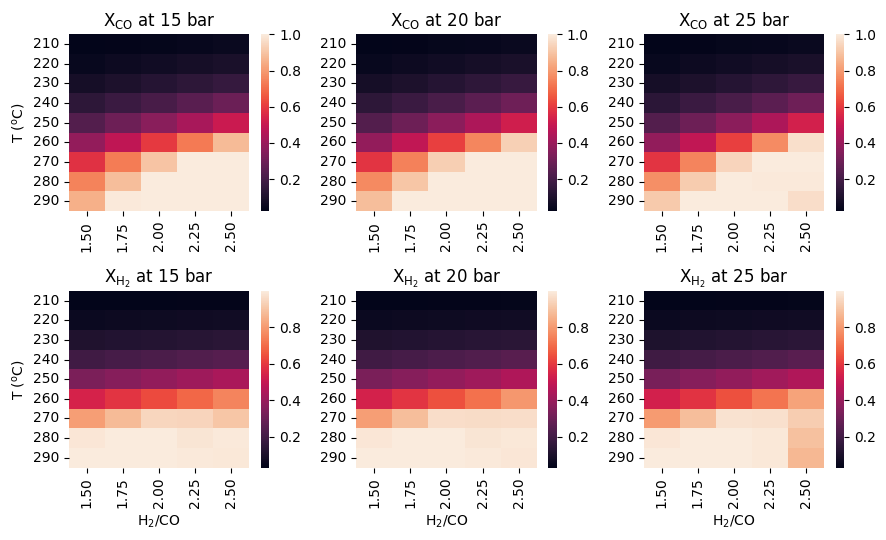

In [10]:
pressures = [15, 20, 25]
variables = [r'$\mathrm{X_{CO}}$', r'$\mathrm{X_{H_2}}$']
fig, ax = plt.subplots(2, 3, figsize=(9, 5.5)) # Slightly wider for clarity

for i, var in enumerate(variables):
    for j, p in enumerate(pressures):
        # 1. Filter and Pivot
        pivot_table = plot_data[
            (plot_data['P (bar)'] == p) & (plot_data['variable'] == var)
        ].pivot(index=r"T ($\mathrm{^o}$C)", columns=r'$\mathrm{H_2/CO}$', values="value")
        
        # 2. Plot Heatmap (cbar_kws removed)
        sns.heatmap(data=pivot_table, ax=ax[i, j])
        
        # 3. Format tick labels
        ax[i, j].set_xticklabels(["{:.2f}".format(x) for x in pivot_table.columns])
        ax[i, j].set_yticklabels(["{:d}".format(int(y)) for y in pivot_table.index])
        
        # 4. Consolidate info into Title
        ax[i, j].set_title(f"{var} at {p} bar")
        
        # Optional: Clean up inner labels for a professional look
        if i != len(variables)-1: ax[i, j].set_xlabel('') # Remove X-label for top row
        if j > 0: ax[i, j].set_ylabel('')  # Remove Y-label for middle/right columns

plt.tight_layout()

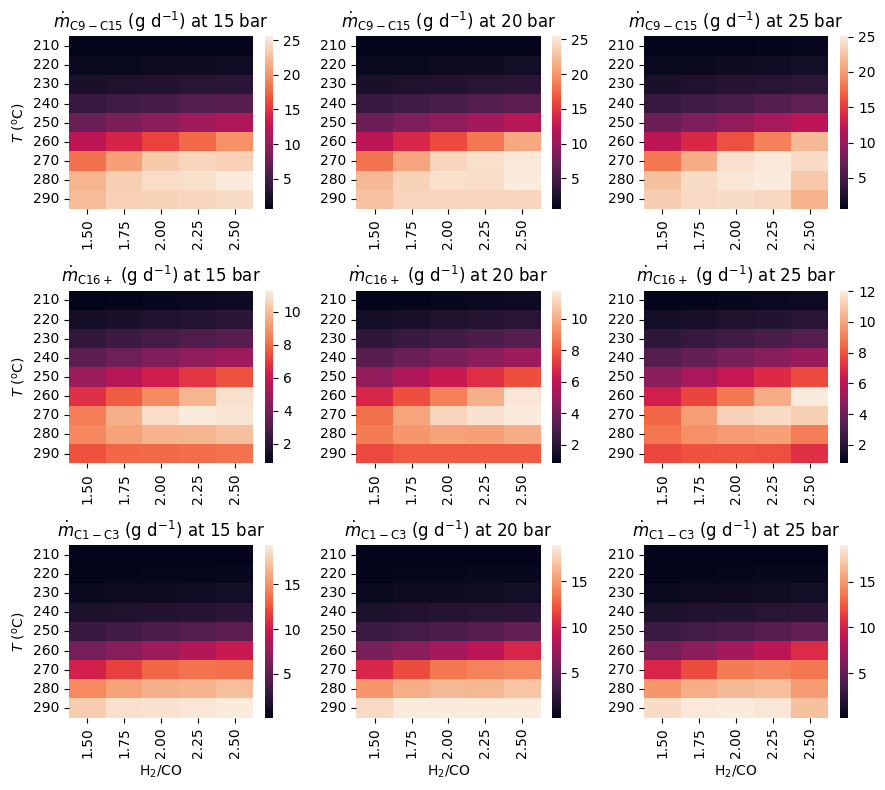

In [11]:
pressures = [15, 20, 25]
variables = [r'$\dot{m}_\mathrm{C9-C15}$ (g/d)', 
             r'$\dot{m}_\mathrm{C16+}$ (g/d)',
             r'$\dot{m}_\mathrm{C1-C3}$ (g/d)']
variables_formatted = {r'$\dot{m}_\mathrm{C9-C15}$ (g/d)': r'$\dot{m}_\mathrm{C9-C15}$ $\mathrm{(g~d^{-1})}$', 
             r'$\dot{m}_\mathrm{C16+}$ (g/d)': r'$\dot{m}_\mathrm{C16+}$ $\mathrm{(g~d^{-1})}$',
             r'$\dot{m}_\mathrm{C1-C3}$ (g/d)': r'$\dot{m}_\mathrm{C1-C3}$ $\mathrm{(g~d^{-1})}$'}
fig, ax = plt.subplots(3, 3, figsize=(9, 8)) # Slightly wider for clarity

for i, var in enumerate(variables):
    for j, p in enumerate(pressures):
        # 1. Filter and Pivot
        pivot_table = plot_data[
            (plot_data['P (bar)'] == p) & (plot_data['variable'] == var)
        ].pivot(index=r"T ($\mathrm{^o}$C)", columns=r'$\mathrm{H_2/CO}$', values="value")
        
        # 2. Plot Heatmap (cbar_kws removed)
        sns.heatmap(data=pivot_table, ax=ax[i, j])
        
        # 3. Format tick labels
        ax[i, j].set_xticklabels(["{:.2f}".format(x) for x in pivot_table.columns])
        ax[i, j].set_yticklabels(["{:d}".format(int(y)) for y in pivot_table.index])
        
        # 4. Consolidate info into Title
        ax[i, j].set_title(f"{variables_formatted[var]} at {p} bar")
        ax[i, j].set_ylabel(r'$T$ ($\mathrm{^o}$C)')

        # Optional: Clean up inner labels for a professional look
        if i != len(variables)-1: ax[i, j].set_xlabel('') # Remove X-label for top row
        if j > 0: ax[i, j].set_ylabel('')  # Remove Y-label for middle/right columns
plt.tight_layout()

fig_name = 'm_out_parametric_study.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

In [12]:
col = r'$\dot{m}_\mathrm{C9-C15}$ (g/d)'
parametric_data.loc[parametric_data[col] == parametric_data[col].max()]

,"$\mathrm{F_{CO,in}}$ (mol/s)","$\mathrm{F_{H_2,in}}$ (mol/s)",P_Pa,T_K,Reactor Energy Flow (W),CO in mass flow (g/d),H2 in mass flow (g/d),C1-C8 mass flow (g/d),C9-C15 mass flow (g/d),C16p mass flow (g/d),...,T ($\mathrm{^o}$C),P (bar),$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\dot{m}_\mathrm{C1-C3}$ (g/d),$\dot{m}_\mathrm{C9-C15}$ (g/d),$\dot{m}_\mathrm{C16+}$ (g/d),$\dot{m}_\mathrm{H_2O}$ (g/d)
115,0.000038,0.000094,1500000.0,553.15,-7.774733,91.392161,16.443678,17.084473,25.560306,10.065945,...,280.0,15.0,1.0,0.989998,51.428571,128.571429,17.084473,25.560306,10.065945,63.441361


In [13]:
parametric_data.loc[
    (parametric_data['P (bar)'] == 20) &
    (parametric_data[r'T ($\mathrm{^o}$C)'] == 280) &
    (parametric_data['$\\mathrm{H_2/CO}$'] == 2)
]

,"$\mathrm{F_{CO,in}}$ (mol/s)","$\mathrm{F_{H_2,in}}$ (mol/s)",P_Pa,T_K,Reactor Energy Flow (W),CO in mass flow (g/d),H2 in mass flow (g/d),C1-C8 mass flow (g/d),C9-C15 mass flow (g/d),C16p mass flow (g/d),...,T ($\mathrm{^o}$C),P (bar),$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\dot{m}_\mathrm{C1-C3}$ (g/d),$\dot{m}_\mathrm{C9-C15}$ (g/d),$\dot{m}_\mathrm{C16+}$ (g/d),$\dot{m}_\mathrm{H_2O}$ (g/d)


In [14]:
col = r'$\dot{m}_\mathrm{C16+}$ (g/d)'
parametric_data.loc[parametric_data[col] == parametric_data[col].max()]

,"$\mathrm{F_{CO,in}}$ (mol/s)","$\mathrm{F_{H_2,in}}$ (mol/s)",P_Pa,T_K,Reactor Energy Flow (W),CO in mass flow (g/d),H2 in mass flow (g/d),C1-C8 mass flow (g/d),C9-C15 mass flow (g/d),C16p mass flow (g/d),...,T ($\mathrm{^o}$C),P (bar),$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\dot{m}_\mathrm{C1-C3}$ (g/d),$\dot{m}_\mathrm{C9-C15}$ (g/d),$\dot{m}_\mathrm{C16+}$ (g/d),$\dot{m}_\mathrm{H_2O}$ (g/d)
131,0.000038,0.000094,2500000.0,533.15,-6.029672,91.392161,16.443678,10.554924,21.834452,12.029094,...,260.0,25.0,0.965658,0.819696,51.428571,128.571429,10.554924,21.834452,12.029094,53.955557


In [15]:
col = r'$\dot{m}_\mathrm{C1-C3}$ (g/d)'
parametric_data.loc[parametric_data[col] == parametric_data[col].max()]

,"$\mathrm{F_{CO,in}}$ (mol/s)","$\mathrm{F_{H_2,in}}$ (mol/s)",P_Pa,T_K,Reactor Energy Flow (W),CO in mass flow (g/d),H2 in mass flow (g/d),C1-C8 mass flow (g/d),C9-C15 mass flow (g/d),C16p mass flow (g/d),...,T ($\mathrm{^o}$C),P (bar),$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\dot{m}_\mathrm{C1-C3}$ (g/d),$\dot{m}_\mathrm{C9-C15}$ (g/d),$\dot{m}_\mathrm{C16+}$ (g/d),$\dot{m}_\mathrm{H_2O}$ (g/d)
116,0.000038,0.000094,1500000.0,563.15,-7.678427,91.392161,16.443678,19.374665,24.520937,8.186641,...,290.0,15.0,1.0,0.986909,51.428571,128.571429,19.374665,24.520937,8.186641,62.276791


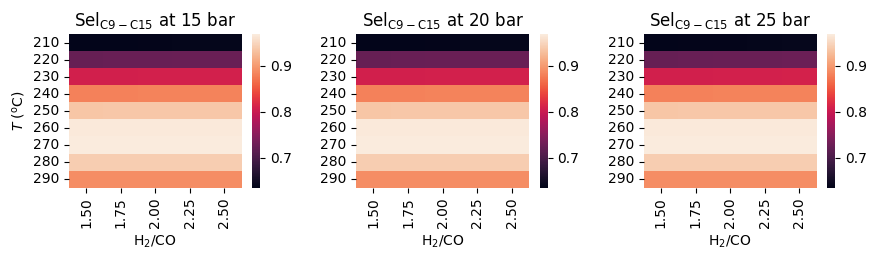

In [16]:
pressures = [15, 20, 25]
variables = [r'$\mathrm{Sel_{C9-C15}}$']
fig, ax = plt.subplots(1,3,figsize=(9, 2.7)) # Slightly wider for clarity

for i, var in enumerate(variables):
    for j, p in enumerate(pressures):
        # 1. Filter and Pivot
        pivot_table = plot_data[
            (plot_data['P (bar)'] == p) & (plot_data['variable'] == var)
        ].pivot(index=r"T ($\mathrm{^o}$C)", columns=r'$\mathrm{H_2/CO}$', values="value")
        
        # 2. Plot Heatmap (cbar_kws removed)
        sns.heatmap(data=pivot_table, ax=ax[j])
        
        # 3. Format tick labels
        ax[j].set_xticklabels(["{:.2f}".format(x) for x in pivot_table.columns])
        ax[j].set_yticklabels(["{:d}".format(int(y)) for y in pivot_table.index])
        
        # 4. Consolidate info into Title
        ax[j].set_title(f"{var} at {p} bar")

        ax[j].set_ylabel(r'$T$ ($\mathrm{^o}$C)')

        # Optional: Clean up inner labels for a professional look
        if i != len(variables)-1: ax[j].set_xlabel('') # Remove X-label for top row
        if j > 0: ax[j].set_ylabel('')  # Remove Y-label for middle/right columns
plt.tight_layout()
fig_name = 'Sel_C9_C15_parametric_study.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

In [17]:
parametric_data.loc[parametric_data[r'$\mathrm{Sel_{C9-C15}}$'] == parametric_data[r'$\mathrm{Sel_{C9-C15}}$'].max()]

,"$\mathrm{F_{CO,in}}$ (mol/s)","$\mathrm{F_{H_2,in}}$ (mol/s)",P_Pa,T_K,Reactor Energy Flow (W),CO in mass flow (g/d),H2 in mass flow (g/d),C1-C8 mass flow (g/d),C9-C15 mass flow (g/d),C16p mass flow (g/d),...,T ($\mathrm{^o}$C),P (bar),$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\dot{m}_\mathrm{C1-C3}$ (g/d),$\dot{m}_\mathrm{C9-C15}$ (g/d),$\dot{m}_\mathrm{C16+}$ (g/d),$\dot{m}_\mathrm{H_2O}$ (g/d)
123,0.000038,0.000094,2000000.0,543.15,-7.371134,91.392161,16.443678,14.338689,25.269482,11.758207,...,270.0,20.0,1.0,0.962217,51.428571,128.571429,14.338689,25.269482,11.758207,63.024313


v0 = 180 # mL / min
v0 = v0 / ( 1000 * 1000 * 60 ) # m3 / s

F0 = v0 * 1e5 / ( 8.314 * 273 ) # mol / s

H2_CO_in = 2
F_H2_in = F0 * (H2_CO_in / ( 1 + H2_CO_in )) # mol / s
F_CO_in = F0 - F_H2_in

param_grid = {'T_K'      : [210 + 273.15, 230 + 273.15, 250 + 273.15, 
                            260 + 273.15, 270 + 273.15, 290 + 273.15], 
              'P_Pa'     : np.concat((np.arange(1e5, 5e5, 0.5e5),
                                      np.arange(5e5, 20e5, 1e5), 
                                      np.arange(20e5, 75e5, 10e5))),
              'F_H2_in'    : [F_H2_in],
              'F_CO_in' : [F_CO_in],
             }

parametric_data_onlyP = pd.DataFrame(ParameterGrid(param_grid))
parametric_data_onlyP = parametric_study(parametric_data_onlyP, num_workers:=16, dwsim_path, sim_path)

parametric_data_onlyP['C9_C15_sel'] = parametric_data_onlyP['C9-C15 mass flow (g/d)']/(
    parametric_data_onlyP[['C1-C8 mass flow (g/d)', 'C16p mass flow (g/d)']].sum(axis = 'columns')
)
parametric_data_onlyP['H2_CO'] = parametric_data_onlyP.F_H2_in / parametric_data_onlyP.F_CO_in
parametric_data_onlyP[r'T ($\mathrm{^o}$C)'] = parametric_data_onlyP.T_K - 273.15
parametric_data_onlyP['P (bar)'] = parametric_data_onlyP.P_Pa / 1e5
parametric_data_onlyP[r'$\mathrm{X_{CO}}$'] = (
    (parametric_data_onlyP.F_CO_in - parametric_data_onlyP['F_Carbon monoxide_out_dwsim']) / parametric_data_onlyP.F_CO_in
)
parametric_data_onlyP[r'$\mathrm{X_{H_2}}$'] = (
    (parametric_data_onlyP.F_H2_in - parametric_data_onlyP['F_Hydrogen_out_dwsim']) / parametric_data_onlyP.F_H2_in
)
parametric_data_onlyP[r'$\mathrm{v_{CO,in}}$ (mL/min)'] = 1000 * 1000 * 60 * parametric_data_onlyP.F_CO_in * 8.314 * 273 / 1e5
parametric_data_onlyP[r'$\mathrm{v_{H_2,in}}$ (mL/min)'] = 1000 * 1000 * 60 * parametric_data_onlyP.F_H2_in * 8.314 * 273 / 1e5

parametric_data_onlyP.to_pickle('parametric_data_onlyP_dwsim.pkl')

In [18]:
parametric_data_onlyP = pd.read_pickle('parametric_data_onlyP_dwsim.pkl')

In [19]:
parametric_data_onlyP = parametric_data_onlyP.rename(columns=new_names_mapping)

In [20]:
parametric_data_onlyP[[r'$\dot{m}_\mathrm{C1-C3}$ (g/d)', 
                 r'$\dot{m}_\mathrm{C9-C15}$ (g/d)', 
                 r'$\dot{m}_\mathrm{C16+}$ (g/d)', 
                 r'$\dot{m}_\mathrm{H_2O}$ (g/d)']] = parametric_data_onlyP[['C1-C8 mass flow (g/d)', 
                                                                        'C9-C15 mass flow (g/d)', 
                                                                        'C16p mass flow (g/d)', 
                                                                        'water mass flow (g/d)']]

In [21]:
parametric_data_onlyP[r'T ($\mathrm{^o}$C)'] = parametric_data_onlyP['T (ºC)']

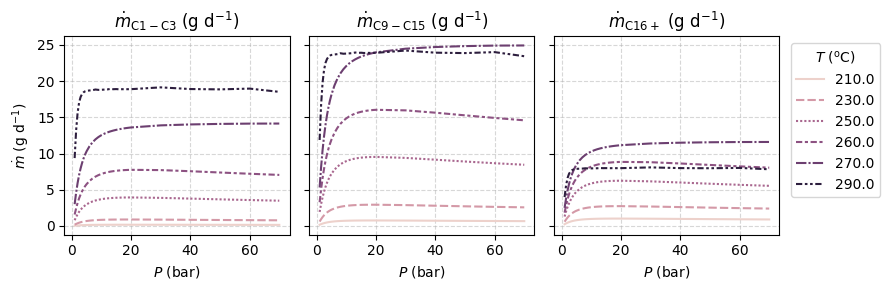

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns (carbon fractions) to iterate over
fractions = [r'$\dot{m}_\mathrm{C1-C3}$ (g/d)',
             r'$\dot{m}_\mathrm{C9-C15}$ (g/d)',
             r'$\dot{m}_\mathrm{C16+}$ (g/d)']

fractions_formatted = {r'$\dot{m}_\mathrm{C1-C3}$ (g/d)': r'$\dot{m}_\mathrm{C1-C3}$ $\mathrm{(g~d^{-1})}$',
             r'$\dot{m}_\mathrm{C9-C15}$ (g/d)': r'$\dot{m}_\mathrm{C9-C15}$ $\mathrm{(g~d^{-1})}$',
             r'$\dot{m}_\mathrm{C16+}$ (g/d)': r'$\dot{m}_\mathrm{C16+}$ $\mathrm{(g~d^{-1})}$'}

# Initialize subplots
fig, ax = plt.subplots(1, 3, figsize=(9, 3), sharey=True)

for i, col in enumerate(fractions):
    # Melt only the necessary columns for the current subplot
    data_melted = parametric_data_onlyP[['P (bar)', r'T ($\mathrm{^o}$C)', col]].melt(
        id_vars=['P (bar)', r'T ($\mathrm{^o}$C)']
    )
    
    # Plotting
    sns.lineplot(
        data=data_melted,
        x='P (bar)',
        y='value',
        hue=r'T ($\mathrm{^o}$C)',
        style=r'T ($\mathrm{^o}$C)',
        ax=ax[i],
        legend=(i == 2) # Show legend only on the last plot to save space
    )
    
    # Formatting each subplot
    ax[i].set_title(fractions_formatted[col])
    ax[i].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[i].set_ylabel(r'$\dot{m}$ $\mathrm{(g~d^{-1})}$' if i == 0 else "")
    ax[i].set_xlabel(r'$P$ (bar)')

# Adjust legend position on the last axis
ax[2].legend(bbox_to_anchor=(1.02, 1), title=r'$T$ ($\mathrm{^o}$C)', loc='upper left')

plt.tight_layout()

# Save logic
fig_name = 'parametric_study_P.pdf'
save_path = f'/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/{fig_name}'
plt.savefig(save_path, bbox_inches='tight')
plt.show()